C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_23156\3563288626.py:132: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_23156\3563288626.py:132: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Malgun Gothic.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])
c:\Users\hisj0\.conda\envs\DL\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\hisj0\.conda\envs\DL\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


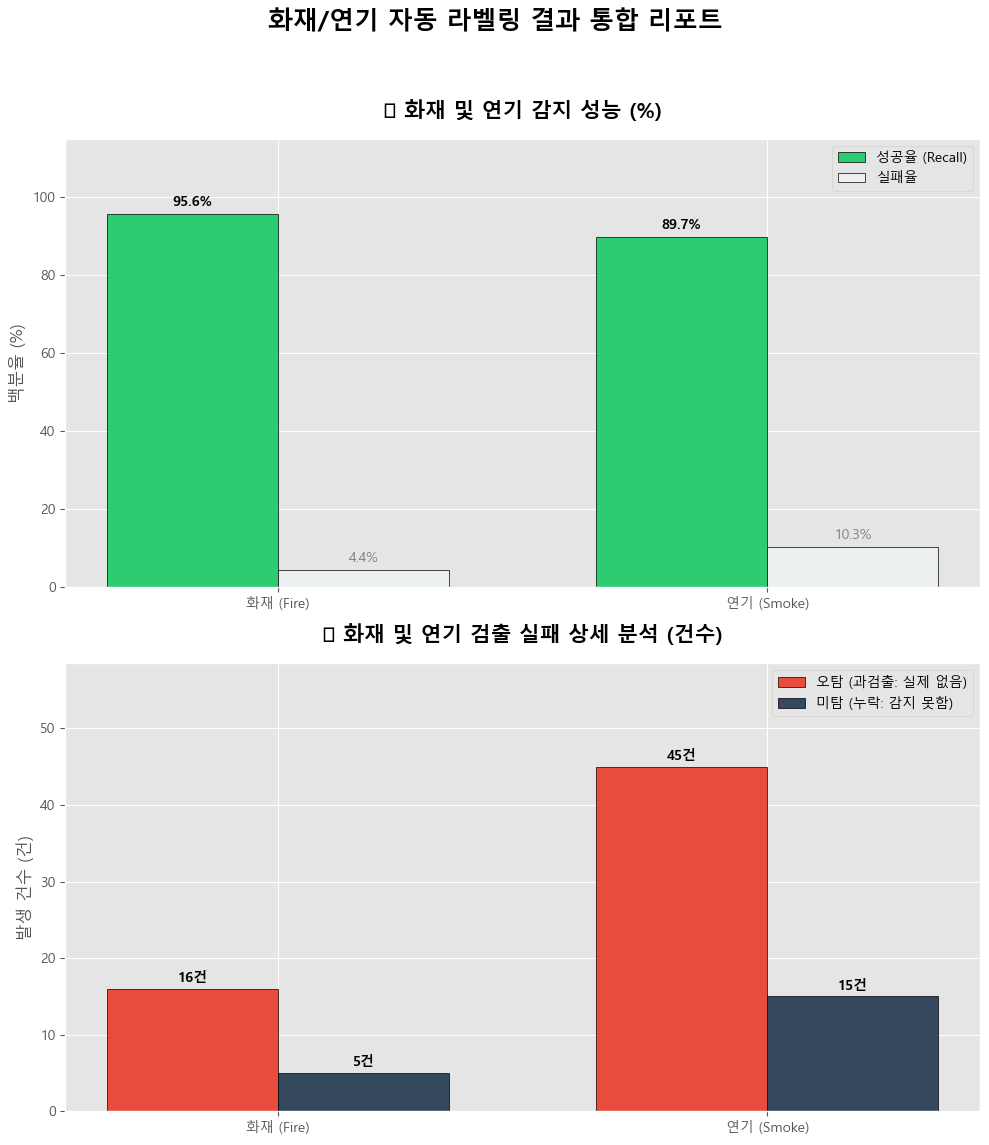

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog, messagebox
from matplotlib import font_manager, rc

# ==========================================
# 0. 한글 폰트 설정
# ==========================================
try:
    if os.name == 'nt':  # Windows
        font_name = font_manager.FontProperties(fname="c:/Windows/Fonts/malgun.ttf").get_name()
        rc('font', family=font_name)
    else:  # Mac
        rc('font', family='AppleGothic')
    plt.rcParams['axes.unicode_minus'] = False
except:
    pass

def select_directories():
    root = tk.Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    messagebox.showinfo("안내", "1. 정답 폴더(GT)와 2. 자동 라벨 폴더(Pred)를 선택하세요.")
    gt_dir = filedialog.askdirectory(title="정답(Manual) 폴더 선택")
    pred_dir = filedialog.askdirectory(title="비교(Auto) 폴더 선택")
    return gt_dir, pred_dir

def get_label_data(file_path):
    data = []
    if os.path.exists(file_path):
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    data.append({'cls': int(parts[0]), 'bbox': [float(p) for p in parts[1:5]]})
    return data

def calculate_iou(box1, box2):
    b1_x1, b1_y1 = box1[0] - box1[2]/2, box1[1] - box1[3]/2
    b1_x2, b1_y2 = box1[0] + box1[2]/2, box1[1] + box1[3]/2
    b2_x1, b2_y1 = box2[0] - box2[2]/2, box2[1] - box2[3]/2
    b2_x2, b2_y2 = box2[0] + box2[2]/2, box2[1] + box2[3]/2
    ix1, iy1 = max(b1_x1, b2_x1), max(b1_y1, b2_y1)
    ix2, iy2 = min(b1_x2, b2_x2), min(b1_y2, b2_y2)
    iw, ih = max(0, ix2 - ix1), max(0, iy2 - iy1)
    ia = iw * ih
    ua = (box1[2] * box1[3]) + (box2[2] * box2[3]) - ia
    return ia / (ua + 1e-6)

def run_analysis():
    GT_DIR, PRED_DIR = select_directories()
    if not GT_DIR or not PRED_DIR: return

    stats = {
        0: {'name': '화재 (Fire)', 'tp': 0, 'fp': 0, 'fn': 0, 'total': 0},
        1: {'name': '연기 (Smoke)', 'tp': 0, 'fp': 0, 'fn': 0, 'total': 0}
    }
    
    gt_files = [f for f in os.listdir(GT_DIR) if f.endswith('.txt')]
    for fname in gt_files:
        gts = get_label_data(os.path.join(GT_DIR, fname))
        preds = get_label_data(os.path.join(PRED_DIR, fname))

        for c in [0, 1]:
            c_gts = [d['bbox'] for d in gts if d['cls'] == c]
            c_preds = [d['bbox'] for d in preds if d['cls'] == c]
            stats[c]['total'] += len(c_gts)
            
            matched = [False] * len(c_gts)
            for pb in c_preds:
                best_iou, bi = 0, -1
                for i, gb in enumerate(c_gts):
                    if not matched[i]:
                        iou = calculate_iou(gb, pb)
                        if iou > best_iou: best_iou, bi = iou, i
                if best_iou >= 0.5:
                    stats[c]['tp'] += 1
                    matched[bi] = True
                else: stats[c]['fp'] += 1
            stats[c]['fn'] += matched.count(False)

    # 데이터 준비
    classes = ['화재 (Fire)', '연기 (Smoke)']
    recalls = [ (stats[c]['tp']/stats[c]['total']*100 if stats[c]['total']>0 else 0) for c in [0, 1] ]
    fails = [ 100 - r for r in recalls ]
    fp_counts = [stats[0]['fp'], stats[1]['fp']]
    fn_counts = [stats[0]['fn'], stats[1]['fn']]

    # 그래프 생성
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 12))
    plt.subplots_adjust(hspace=0.3)

    # --- 그래프 1: 화재/연기 성공율 및 실패율 (%) ---
    x = np.arange(len(classes))
    width = 0.35
    ax1.bar(x - width/2, recalls, width, label='성공율 (Recall)', color='#2ecc71', edgecolor='black')
    ax1.bar(x + width/2, fails, width, label='실패율', color='#ecf0f1', edgecolor='black')
    
    ax1.set_title('✅ 화재 및 연기 감지 성능 (%)', fontsize=15, pad=15, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(classes)
    ax1.set_ylim(0, 115)
    ax1.set_ylabel('백분율 (%)')
    ax1.legend()

    for i in x:
        ax1.text(i - width/2, recalls[i] + 2, f'{recalls[i]:.1f}%', ha='center', fontweight='bold')
        ax1.text(i + width/2, fails[i] + 2, f'{fails[i]:.1f}%', ha='center', color='gray')

    # --- 그래프 2: 화재/연기 검출 실패 건수 분석 (오탐/미탐) ---
    ax2.bar(x - width/2, fp_counts, width, label='오탐 (과검출: 실제 없음)', color='#e74c3c', edgecolor='black')
    ax2.bar(x + width/2, fn_counts, width, label='미탐 (누락: 감지 못함)', color='#34495e', edgecolor='black')
    
    ax2.set_title('❌ 화재 및 연기 검출 실패 상세 분석 (건수)', fontsize=15, pad=15, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(classes)
    ax2.set_ylabel('발생 건수 (건)')
    ax2.legend()

    max_count = max(max(fp_counts), max(fn_counts)) if max(max(fp_counts), max(fn_counts)) > 0 else 10
    ax2.set_ylim(0, max_count * 1.3)

    for i in x:
        ax2.text(i - width/2, fp_counts[i] + (max_count * 0.02), f'{fp_counts[i]}건', ha='center', fontweight='bold')
        ax2.text(i + width/2, fn_counts[i] + (max_count * 0.02), f'{fn_counts[i]}건', ha='center', fontweight='bold')

    

    plt.suptitle("화재/연기 자동 라벨링 결과 통합 리포트", fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

if __name__ == "__main__":
    run_analysis()